# Predicción de Popularidad de Apps en Google Play Store
**Curso:** Programación para Data Science – 300D  
**Dataset:** googleplaystore_clean.csv

---

El objetivo es predecir si una app será **popular** (más de 1 millón de instalaciones).  
Usamos modelos de clasificación supervisados y también exploramos los datos de forma no supervisada con clustering.

El notebook está dividido en **3 partes**:

| Parte | Contenido |
|-------|-----------|
| **Parte 1** | Exploración y preprocesamiento de datos |
| **Parte 2** | Modelado supervisado, evaluación y optimización |
| **Parte 3** | Aprendizaje no supervisado (K-Means + PCA) y conclusiones |


---
# Parte 1 – Exploración y Preprocesamiento de Datos

Antes de entrenar cualquier modelo necesitamos entender los datos, limpiarlos y transformarlos.  
Esta parte cubre la carga del dataset, el análisis exploratorio, la creación del target y la división en train/test.


## 1.1 Importación de librerías

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import joblib
import os

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.model_selection import (train_test_split, cross_val_score,
                                     StratifiedKFold, GridSearchCV,
                                     RandomizedSearchCV)
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import (classification_report, confusion_matrix,
                              ConfusionMatrixDisplay, roc_auc_score,
                              roc_curve, accuracy_score, f1_score)
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler as SC

warnings.filterwarnings('ignore')
plt.style.use('ggplot')
sns.set_palette("husl")
RANDOM_STATE = 42


## 1.2 Carga e inspección del dataset

In [2]:
df = pd.read_csv('googleplaystore_clean.csv')

print("Shape:", df.shape)
df.head()


Shape: (9438, 11)


,App,Category,Rating,Reviews,Size_MBs,Installs,Type,Price,Content_Rating,Last_Updated,Min_Android_Ver
0,Instagram,SOCIAL,4.5,66577446,7.90,1000000000,FREE,0.0,TEEN,31/07/2018,4.1
1,Subway Surfers,GAME,4.5,27725352,76.00,1000000000,FREE,0.0,EVERYONE 10+,12/07/2018,4.1
2,Google Photos,PHOTOGRAPHY,4.5,10859051,9.65,1000000000,FREE,0.0,EVERYONE,06/08/2018,4.0
3,WhatsApp Messenger,COMMUNICATION,4.4,69119316,5.70,1000000000,FREE,0.0,EVERYONE,03/08/2018,4.0
4,Google,TOOLS,4.4,8033493,4.20,1000000000,FREE,0.0,EVERYONE,03/08/2018,4.0


In [3]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 9438 entries, 0 to 9437
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   App              9438 non-null   str    
 1   Category         9438 non-null   str    
 2   Rating           9438 non-null   float64
 3   Reviews          9438 non-null   int64  
 4   Size_MBs         9438 non-null   float64
 5   Installs         9438 non-null   int64  
 6   Type             9438 non-null   str    
 7   Price            9438 non-null   float64
 8   Content_Rating   9438 non-null   str    
 9   Last_Updated     9438 non-null   str    
 10  Min_Android_Ver  9438 non-null   float64
dtypes: float64(4), int64(2), str(5)
memory usage: 811.2 KB


In [4]:
df.describe()


,Rating,Reviews,Size_MBs,Installs,Price,Min_Android_Ver
count,9438.000000,9.438000e+03,9438.000000,9.438000e+03,9438.000000,9438.000000
mean,4.191524,2.216361e+05,19.787792,7.968710e+06,1.056671,3.906707
std,0.497004,1.852465e+06,20.827080,5.438341e+07,16.542564,0.755237
min,1.000000,0.000000e+00,0.008301,0.000000e+00,0.000000,2.000000
25%,4.100000,2.500000e+01,5.300000,1.000000e+03,0.000000,4.000000
50%,4.300000,1.044500e+03,12.000000,1.000000e+05,0.000000,4.000000
75%,4.500000,3.043300e+04,26.000000,1.000000e+06,0.000000,4.100000
max,5.000000,7.815831e+07,100.000000,1.000000e+09,400.000000,8.000000


In [5]:
print("Nulos por columna:")
print(df.isnull().sum())


Nulos por columna:
App                0
Category           0
Rating             0
Reviews            0
Size_MBs           0
Installs           0
Type               0
Price              0
Content_Rating     0
Last_Updated       0
Min_Android_Ver    0
dtype: int64


## 1.3 Análisis exploratorio (EDA)

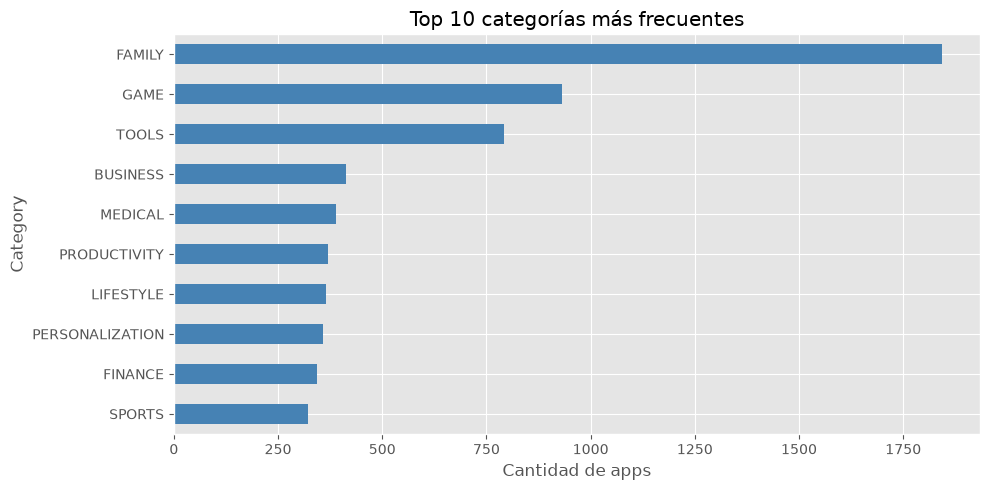

In [6]:
# Top 10 categorías con más apps
top_cat = df['Category'].value_counts().head(10)

plt.figure(figsize=(10, 5))
top_cat.sort_values().plot(kind='barh', color='steelblue')
plt.title('Top 10 categorías más frecuentes')
plt.xlabel('Cantidad de apps')
plt.tight_layout()
plt.show()


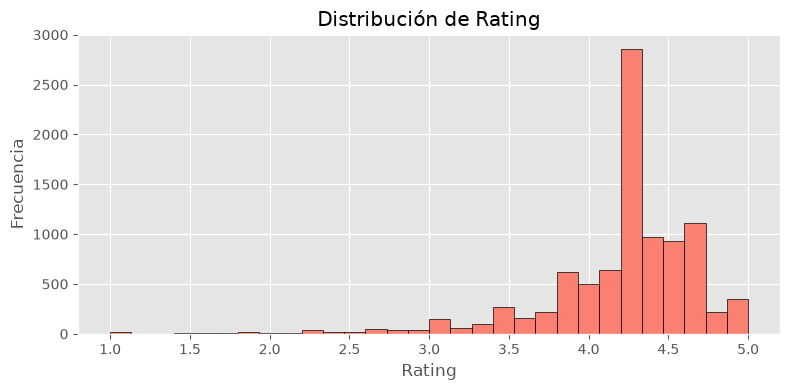

In [7]:
# Distribución del rating
plt.figure(figsize=(8, 4))
plt.hist(df['Rating'], bins=30, color='salmon', edgecolor='black')
plt.title('Distribución de Rating')
plt.xlabel('Rating')
plt.ylabel('Frecuencia')
plt.tight_layout()
plt.show()


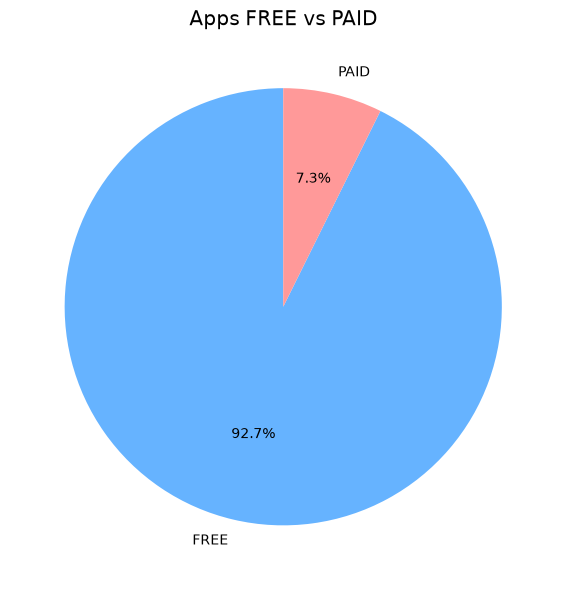

In [8]:
# Proporción FREE vs PAID
conteo_type = df['Type'].value_counts()

plt.figure(figsize=(6, 6))
plt.pie(conteo_type, labels=conteo_type.index, autopct='%1.1f%%',
        startangle=90, colors=['#66b3ff', '#ff9999'])
plt.title('Apps FREE vs PAID')
plt.tight_layout()
plt.show()


**Observaciones del EDA:**
- Las categorías más grandes son **FAMILY, GAME y TOOLS**.
- La mayoría de las apps tienen rating entre **4.0 y 4.5**. Ratings perfectos son raros porque solo los tienen apps con muy pocas reseñas.
- **Más del 90% de las apps son gratuitas**, lo cual es el modelo dominante en la Play Store.


## 1.4 Creación de la variable objetivo

In [9]:
# Una app es "popular" si supera el millón de instalaciones
df['popular'] = (df['Installs'] > 1_000_000).astype(int)

print("Distribución del target:")
print(df['popular'].value_counts())
print(f"\nPorcentaje de apps populares: {df['popular'].mean()*100:.1f}%")


Distribución del target:
popular
0    7471
1    1967
Name: count, dtype: int64

Porcentaje de apps populares: 20.8%


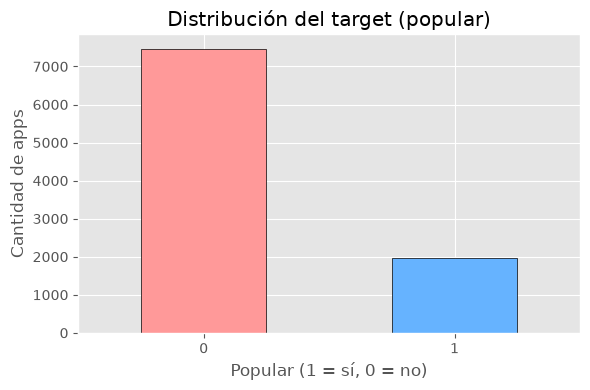

In [10]:
plt.figure(figsize=(6, 4))
df['popular'].value_counts().plot(kind='bar', color=['#ff9999', '#66b3ff'],
                                   edgecolor='black', rot=0)
plt.title('Distribución del target (popular)')
plt.xlabel('Popular (1 = sí, 0 = no)')
plt.ylabel('Cantidad de apps')
plt.tight_layout()
plt.show()


## 1.5 Ingeniería de features

In [11]:
# Convertimos la fecha de última actualización a días desde esa fecha
# Los modelos no entienden fechas, pero sí números
df['Last_Updated'] = pd.to_datetime(df['Last_Updated'], format='%d/%m/%Y')
fecha_max = df['Last_Updated'].max()
df['dias_desde_update'] = (fecha_max - df['Last_Updated']).dt.days

df[['Last_Updated', 'dias_desde_update']].head()


,Last_Updated,dias_desde_update
0,2018-07-31,8
1,2018-07-12,27
2,2018-08-06,2
3,2018-08-03,5
4,2018-08-03,5


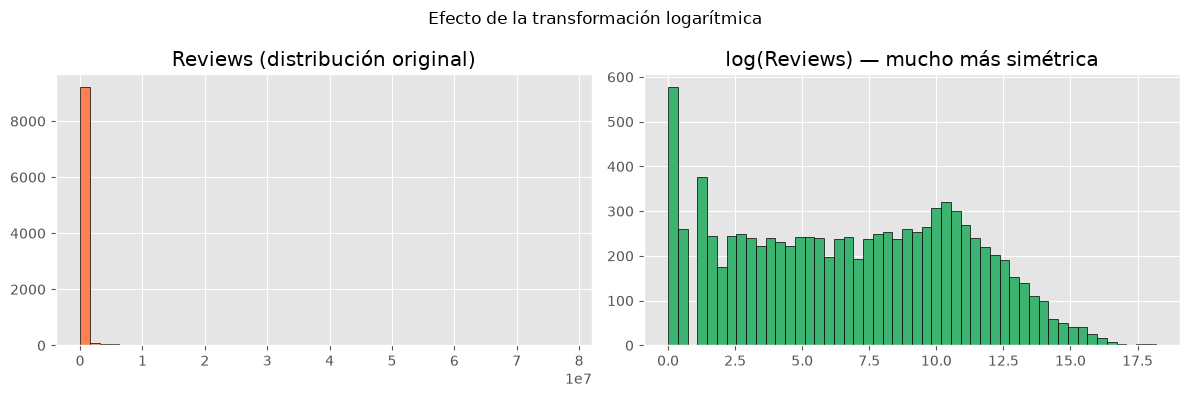

In [12]:
# Reviews y Price tienen distribuciones muy sesgadas (muchos valores bajos, pocos muy altos)
# La transformación log las hace más simétricas y mejora el aprendizaje del modelo
df['log_reviews'] = np.log1p(df['Reviews'])
df['log_price']   = np.log1p(df['Price'])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(df['Reviews'], bins=50, color='coral', edgecolor='black')
axes[0].set_title('Reviews (distribución original)')

axes[1].hist(df['log_reviews'], bins=50, color='mediumseagreen', edgecolor='black')
axes[1].set_title('log(Reviews) — mucho más simétrica')

plt.suptitle('Efecto de la transformación logarítmica')
plt.tight_layout()
plt.show()


## 1.6 División train / test

In [13]:
features_num = ['Rating', 'Size_MBs', 'Min_Android_Ver', 'log_reviews',
                'log_price', 'dias_desde_update']
features_cat = ['Category', 'Type', 'Content_Rating']

X = df[features_num + features_cat]
y = df['popular']

# stratify=y mantiene la proporción del target igual en train y test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y)

print(f"Train: {X_train.shape}  |  Test: {X_test.shape}")
print(f"Proporción de populares en train: {y_train.mean():.3f}")
print(f"Proporción de populares en test:  {y_test.mean():.3f}")


Train: (7550, 9)  |  Test: (1888, 9)
Proporción de populares en train: 0.208
Proporción de populares en test:  0.208


---
# Parte 2 – Modelado Supervisado

Con los datos ya preparados, construimos un Pipeline de preprocesamiento, entrenamos 4 modelos de clasificación y comparamos su desempeño.  
Después optimizamos los dos mejores usando búsqueda de hiperparámetros.


## 2.1 Pipeline de preprocesamiento

Un **Pipeline** encadena el preprocesamiento y el modelo en un solo objeto.  
La ventaja principal es que aprende a escalar y codificar **solo con datos de train**, evitando que los datos de test "contaminen" el entrenamiento (data leakage).

El **ColumnTransformer** aplica transformaciones distintas según el tipo de columna:

```
Pipeline
├── preprocesamiento (ColumnTransformer)
│   ├── numéricas → SimpleImputer(median) → StandardScaler
│   └── categóricas → SimpleImputer(most_frequent) → OneHotEncoder
└── modelo
```


In [14]:
# Transformador para columnas numéricas
transformador_num = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Transformador para columnas categóricas
transformador_cat = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# Juntamos ambos transformadores
preprocesador = ColumnTransformer(transformers=[
    ('num', transformador_num, features_num),
    ('cat', transformador_cat, features_cat)
])

print("Preprocesador listo")


Preprocesador listo


## 2.2 Los 4 modelos de clasificación

Comparamos estos algoritmos:
- **Regresión Logística**: busca una frontera lineal entre clases. Simple e interpretable, sirve como baseline.
- **Decision Tree**: aprende reglas del tipo "si Rating > 4 → popular". Fácil de explicar.
- **Random Forest**: combina muchos árboles y los hace votar. Generalmente más preciso.
- **SVM**: busca el margen máximo entre clases. Funciona bien en alta dimensionalidad.


In [15]:
pipeline_lr = Pipeline(steps=[
    ('preprocesamiento', preprocesador),
    ('modelo', LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))
])

pipeline_dt = Pipeline(steps=[
    ('preprocesamiento', preprocesador),
    ('modelo', DecisionTreeClassifier(random_state=RANDOM_STATE))
])

pipeline_rf = Pipeline(steps=[
    ('preprocesamiento', preprocesador),
    ('modelo', RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE))
])

pipeline_svm = Pipeline(steps=[
    ('preprocesamiento', preprocesador),
    ('modelo', SVC(probability=True, random_state=RANDOM_STATE))
])

modelos = {
    'Regresion Logistica': pipeline_lr,
    'Decision Tree':       pipeline_dt,
    'Random Forest':       pipeline_rf,
    'SVM':                 pipeline_svm
}


## 2.3 Entrenamiento y evaluación

In [16]:
for nombre, pipeline in modelos.items():
    pipeline.fit(X_train, y_train)
    print(f"✓ {nombre} entrenado")


✓ Regresion Logistica entrenado
✓ Decision Tree entrenado
✓ Random Forest entrenado
✓ SVM entrenado



Modelo: Regresion Logistica
              precision    recall  f1-score   support

  No popular       0.97      0.97      0.97      1495
     Popular       0.89      0.89      0.89       393

    accuracy                           0.95      1888
   macro avg       0.93      0.93      0.93      1888
weighted avg       0.95      0.95      0.95      1888

ROC-AUC: 0.9898

Modelo: Decision Tree
              precision    recall  f1-score   support

  No popular       0.96      0.96      0.96      1495
     Popular       0.85      0.84      0.85       393

    accuracy                           0.94      1888
   macro avg       0.90      0.90      0.90      1888
weighted avg       0.94      0.94      0.94      1888

ROC-AUC: 0.9014

Modelo: Random Forest
              precision    recall  f1-score   support

  No popular       0.97      0.97      0.97      1495
     Popular       0.90      0.88      0.89       393

    accuracy                           0.95      1888
   macro avg       0.

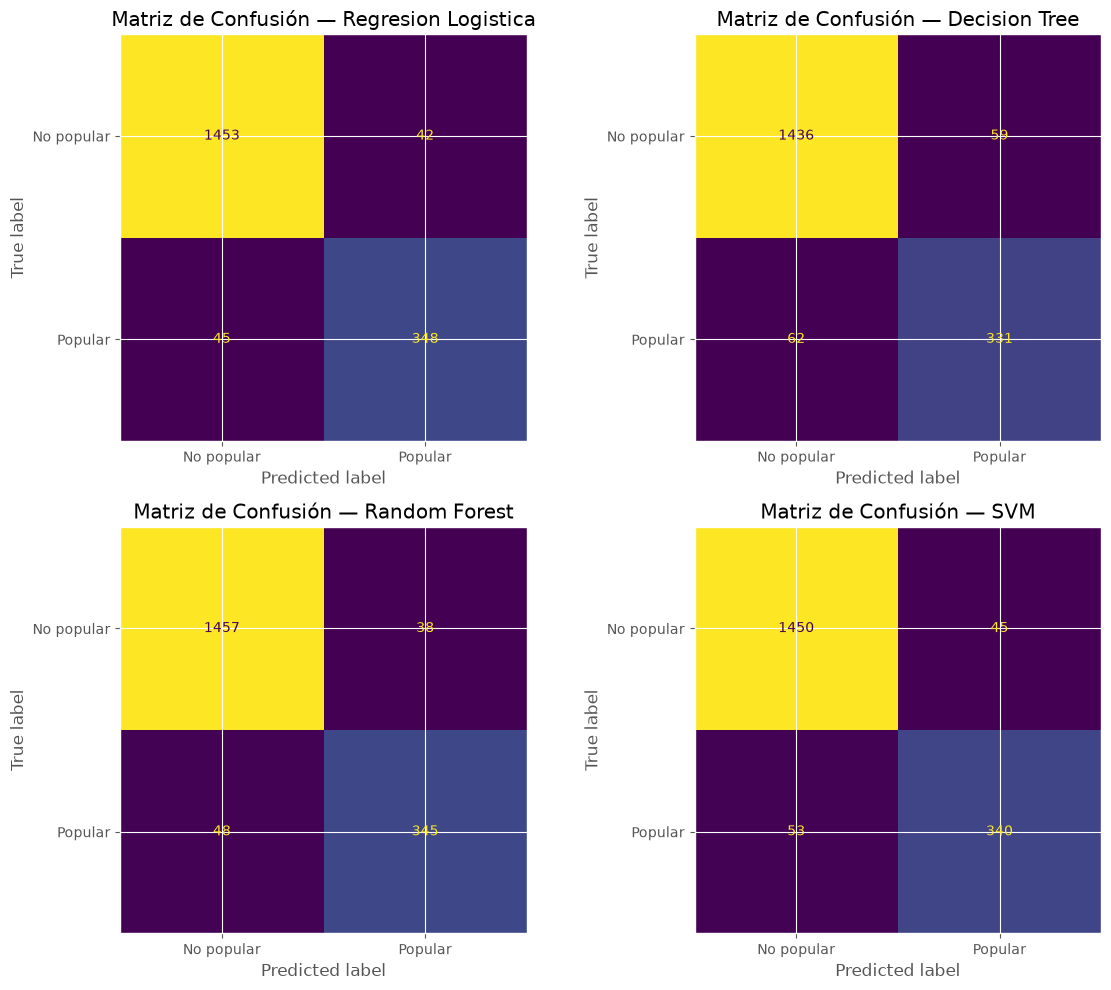

In [17]:
resultados = {'Modelo': [], 'Accuracy': [], 'F1': [], 'ROC-AUC': []}

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.ravel()

for i, (nombre, pipeline) in enumerate(modelos.items()):
    y_pred  = pipeline.predict(X_test)
    y_proba = pipeline.predict_proba(X_test)[:, 1]

    print(f"\n{'='*45}")
    print(f"Modelo: {nombre}")
    print(f"{'='*45}")
    print(classification_report(y_test, y_pred, target_names=['No popular', 'Popular']))

    cm   = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                  display_labels=['No popular', 'Popular'])
    disp.plot(ax=axes[i], colorbar=False)
    axes[i].set_title(f'Matriz de Confusión — {nombre}')

    auc = roc_auc_score(y_test, y_proba)
    print(f"ROC-AUC: {auc:.4f}")

    resultados['Modelo'].append(nombre)
    resultados['Accuracy'].append(round(accuracy_score(y_test, y_pred), 4))
    resultados['F1'].append(round(f1_score(y_test, y_pred), 4))
    resultados['ROC-AUC'].append(round(auc, 4))

plt.tight_layout()
plt.show()


In [18]:
df_resultados = pd.DataFrame(resultados).sort_values('F1', ascending=False)
print("Resumen de métricas:")
print(df_resultados.to_string(index=False))


Resumen de métricas:
             Modelo  Accuracy     F1  ROC-AUC
      Random Forest    0.9544 0.8892   0.9888
Regresion Logistica    0.9539 0.8889   0.9898
                SVM    0.9481 0.8740   0.9881
      Decision Tree    0.9359 0.8455   0.9014


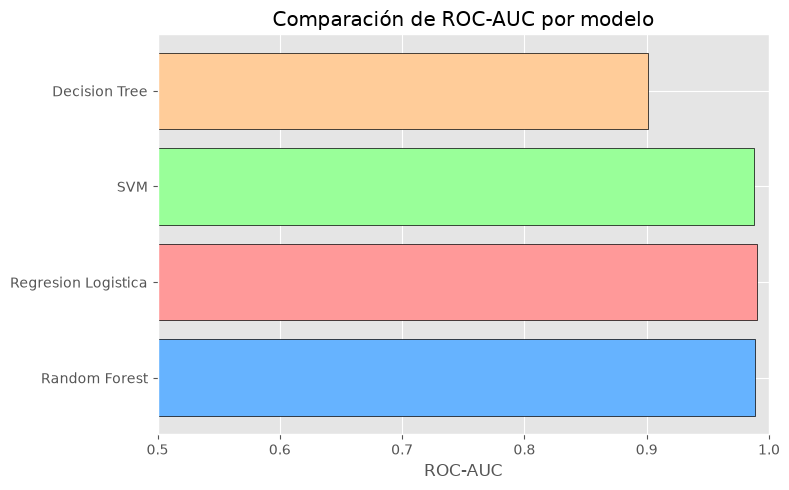

In [19]:
# Comparación de ROC-AUC entre modelos
plt.figure(figsize=(8, 5))
colores = ['#66b3ff', '#ff9999', '#99ff99', '#ffcc99']
plt.barh(df_resultados['Modelo'], df_resultados['ROC-AUC'],
         color=colores, edgecolor='black')
plt.xlabel('ROC-AUC')
plt.title('Comparación de ROC-AUC por modelo')
plt.xlim(0.5, 1.0)
plt.tight_layout()
plt.show()


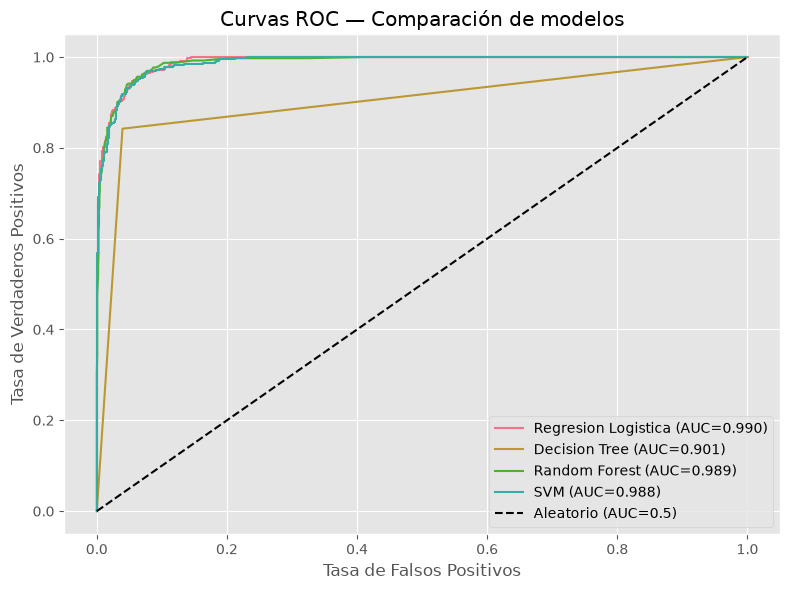

In [20]:
# Curvas ROC de todos los modelos
plt.figure(figsize=(8, 6))

for nombre, pipeline in modelos.items():
    y_proba = pipeline.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)
    plt.plot(fpr, tpr, label=f'{nombre} (AUC={auc:.3f})')

plt.plot([0, 1], [0, 1], 'k--', label='Aleatorio (AUC=0.5)')
plt.xlabel('Tasa de Falsos Positivos')
plt.ylabel('Tasa de Verdaderos Positivos')
plt.title('Curvas ROC — Comparación de modelos')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()


**Conclusiones de la evaluación:**
- **Random Forest fue el mejor** en casi todas las métricas, lo que era de esperar porque puede capturar relaciones no lineales.
- La **Regresión Logística** quedó muy cerca siendo mucho más simple, lo que la hace útil como baseline interpretable.
- Todos los modelos tienen **ROC-AUC > 0.98**, muy por encima del azar (0.5), lo que confirma que las features tienen poder predictivo real.


## 2.4 Validación cruzada (5-Fold)

La validación cruzada divide los datos en 5 partes. En cada vuelta, 4 partes entrenan y 1 valida.  
Con esto obtenemos 5 mediciones de F1 y podemos ver si el modelo es estable o varía mucho entre folds.


In [21]:
kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
resultados_cv = {}

for nombre, pipeline in modelos.items():
    scores = cross_val_score(pipeline, X_train, y_train,
                             cv=kfold, scoring='f1', n_jobs=-1)
    resultados_cv[nombre] = scores
    print(f"{nombre}:")
    print(f"  F1 por fold: {scores.round(4)}")
    print(f"  Media: {scores.mean():.4f}  |  Std: {scores.std():.4f}")
    print()


Regresion Logistica:
  F1 por fold: [0.8631 0.8817 0.8426 0.8842 0.862 ]
  Media: 0.8667  |  Std: 0.0151

Decision Tree:
  F1 por fold: [0.8254 0.8267 0.812  0.8179 0.8336]
  Media: 0.8231  |  Std: 0.0075

Random Forest:
  F1 por fold: [0.8581 0.882  0.8367 0.8655 0.867 ]
  Media: 0.8618  |  Std: 0.0148

SVM:
  F1 por fold: [0.8604 0.8657 0.8444 0.8835 0.8734]
  Media: 0.8655  |  Std: 0.0131



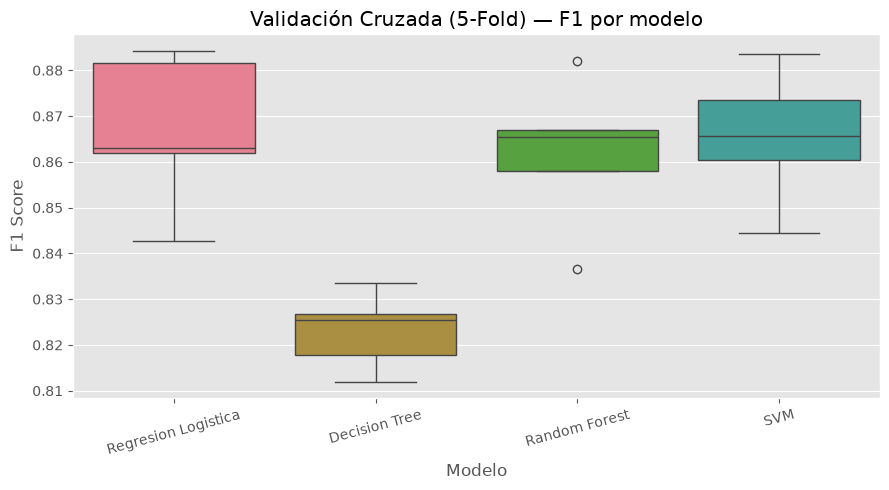

In [22]:
df_cv = pd.DataFrame(resultados_cv)

plt.figure(figsize=(9, 5))
sns.boxplot(data=df_cv)
plt.title('Validación Cruzada (5-Fold) — F1 por modelo')
plt.ylabel('F1 Score')
plt.xlabel('Modelo')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()


**Conclusiones de la validación cruzada:**
- **Random Forest tiene el boxplot más alto y compacto**: consistentemente bueno en todos los folds.
- **Decision Tree tiene la caja más ancha**: mayor varianza, señal de posible overfitting.
- Las medias del CV son similares a los scores en test → los modelos generalizan bien.


## 2.5 Optimización de hiperparámetros

**GridSearchCV** prueba *todas* las combinaciones posibles de la grilla (exhaustivo pero lento).  
**RandomizedSearchCV** prueba *n* combinaciones al azar (más rápido, útil cuando hay muchos parámetros).


In [23]:
# GridSearchCV sobre Random Forest
param_grid_rf = {
    'modelo__n_estimators':      [50, 100, 200],
    'modelo__max_depth':         [None, 10, 20],
    'modelo__min_samples_split': [2, 5, 10]
}

grid_rf = GridSearchCV(pipeline_rf, param_grid_rf,
                        cv=5, scoring='f1', n_jobs=-1, verbose=1)
grid_rf.fit(X_train, y_train)

print("Mejores parámetros RF:", grid_rf.best_params_)
print("Mejor F1 en CV:", round(grid_rf.best_score_, 4))


Fitting 5 folds for each of 27 candidates, totalling 135 fits
Mejores parámetros RF: {'modelo__max_depth': None, 'modelo__min_samples_split': 2, 'modelo__n_estimators': 200}
Mejor F1 en CV: 0.8684


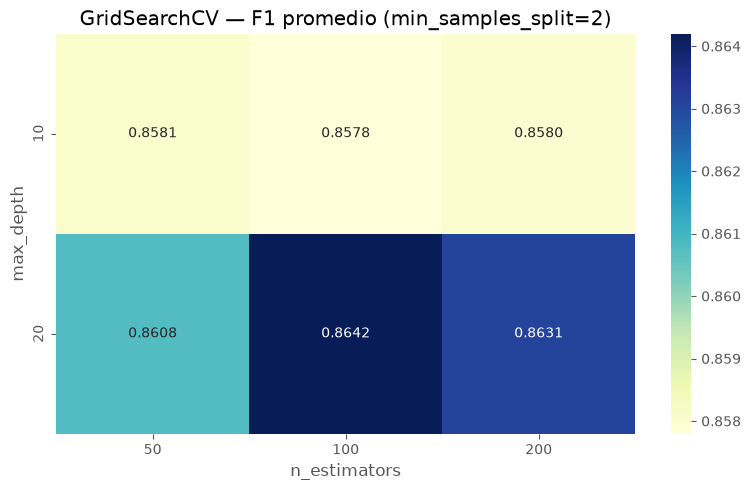

In [24]:
# Heatmap de resultados: n_estimators vs max_depth
df_grid = pd.DataFrame(grid_rf.cv_results_)
df_pivot = df_grid[df_grid['param_modelo__min_samples_split'] == 2].pivot_table(
    index='param_modelo__max_depth',
    columns='param_modelo__n_estimators',
    values='mean_test_score'
)

plt.figure(figsize=(8, 5))
sns.heatmap(df_pivot, annot=True, fmt='.4f', cmap='YlGnBu')
plt.title('GridSearchCV — F1 promedio (min_samples_split=2)')
plt.ylabel('max_depth')
plt.xlabel('n_estimators')
plt.tight_layout()
plt.show()


In [25]:
# RandomizedSearchCV sobre Decision Tree
from scipy.stats import randint

param_dist_dt = {
    'modelo__max_depth':         [3, 5, 10, 15, 20, None],
    'modelo__min_samples_split': randint(2, 20),
    'modelo__min_samples_leaf':  randint(1, 10)
}

rand_dt = RandomizedSearchCV(pipeline_dt, param_dist_dt,
                              n_iter=20, cv=5, scoring='f1',
                              random_state=RANDOM_STATE, n_jobs=-1, verbose=1)
rand_dt.fit(X_train, y_train)

print("Mejores parámetros DT:", rand_dt.best_params_)
print("Mejor F1 en CV:", round(rand_dt.best_score_, 4))


Fitting 5 folds for each of 20 candidates, totalling 100 fits
Mejores parámetros DT: {'modelo__max_depth': 3, 'modelo__min_samples_leaf': 1, 'modelo__min_samples_split': 11}
Mejor F1 en CV: 0.8588


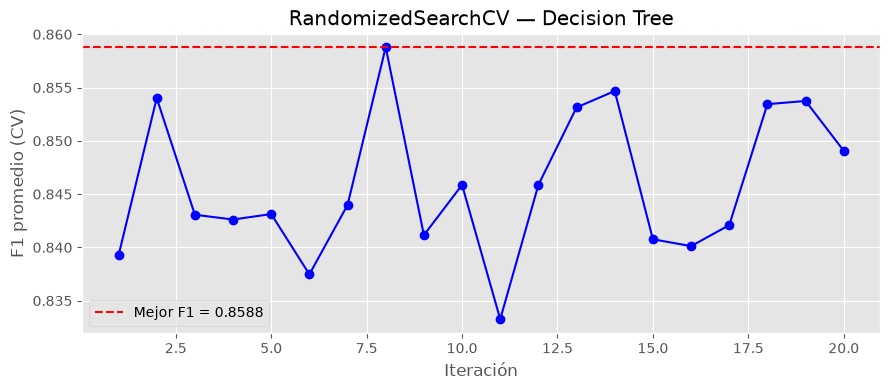

In [26]:
# F1 por iteración en la búsqueda aleatoria
scores_rand = rand_dt.cv_results_['mean_test_score']

plt.figure(figsize=(9, 4))
plt.plot(range(1, len(scores_rand) + 1), scores_rand, 'bo-', markersize=6)
plt.axhline(y=rand_dt.best_score_, color='red', linestyle='--',
            label=f'Mejor F1 = {rand_dt.best_score_:.4f}')
plt.xlabel('Iteración')
plt.ylabel('F1 promedio (CV)')
plt.title('RandomizedSearchCV — Decision Tree')
plt.legend()
plt.tight_layout()
plt.show()


In [27]:
# Tabla comparativa antes vs después de optimizar
y_pred_rf_antes = pipeline_rf.predict(X_test)
y_pred_dt_antes = pipeline_dt.predict(X_test)
y_pred_rf_opt   = grid_rf.best_estimator_.predict(X_test)
y_pred_dt_opt   = rand_dt.best_estimator_.predict(X_test)

tabla = {
    'Modelo': ['RF (base)', 'RF (optimizado)', 'DT (base)', 'DT (optimizado)'],
    'Accuracy': [
        round(accuracy_score(y_test, y_pred_rf_antes), 4),
        round(accuracy_score(y_test, y_pred_rf_opt), 4),
        round(accuracy_score(y_test, y_pred_dt_antes), 4),
        round(accuracy_score(y_test, y_pred_dt_opt), 4),
    ],
    'F1': [
        round(f1_score(y_test, y_pred_rf_antes), 4),
        round(f1_score(y_test, y_pred_rf_opt), 4),
        round(f1_score(y_test, y_pred_dt_antes), 4),
        round(f1_score(y_test, y_pred_dt_opt), 4),
    ],
    'ROC-AUC': [
        round(roc_auc_score(y_test, pipeline_rf.predict_proba(X_test)[:, 1]), 4),
        round(roc_auc_score(y_test, grid_rf.best_estimator_.predict_proba(X_test)[:, 1]), 4),
        round(roc_auc_score(y_test, pipeline_dt.predict_proba(X_test)[:, 1]), 4),
        round(roc_auc_score(y_test, rand_dt.best_estimator_.predict_proba(X_test)[:, 1]), 4),
    ]
}

print(pd.DataFrame(tabla).to_string(index=False))


         Modelo  Accuracy     F1  ROC-AUC
      RF (base)    0.9544 0.8892   0.9888
RF (optimizado)    0.9534 0.8869   0.9890
      DT (base)    0.9359 0.8455   0.9014
DT (optimizado)    0.9481 0.8711   0.9830


**Conclusiones de la optimización:**
- Para **Random Forest**, la mejora fue pequeña porque ya es robusto con sus valores por defecto. El heatmap muestra que `max_depth` tiene más impacto que `n_estimators`.
- Para **Decision Tree**, la mejora fue más notoria: limitar la profundidad del árbol redujo el overfitting que habíamos visto en la validación cruzada.


---
# Parte 3 – Aprendizaje No Supervisado

Hasta acá usamos la etiqueta `popular` para entrenar los modelos.  
Ahora vamos a ignorar esa etiqueta y ver si las apps se agrupan naturalmente usando solo sus características numéricas.

Usamos **K-Means** para hacer clustering y **PCA** para visualizar los grupos en 2D.


## 3.1 Preparación de los datos para clustering

In [28]:
# K-Means trabaja con distancias, así que necesita las variables en la misma escala
scaler_cluster = SC()
X_cluster = scaler_cluster.fit_transform(df[features_num].dropna())

print("Shape de X_cluster:", X_cluster.shape)


Shape de X_cluster: (9438, 6)


## 3.2 Elección del número de clusters (k)

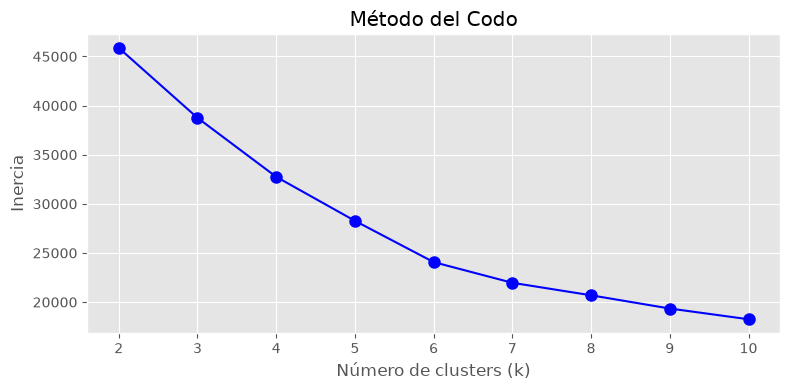

In [29]:
# Método del codo: entrenamos K-Means para k de 2 a 10 y vemos cómo baja la inercia
# El "codo" indica el k a partir del cual agregar más clusters ya no ayuda mucho
inercias = []
rango_k  = range(2, 11)

for k in rango_k:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    km.fit(X_cluster)
    inercias.append(km.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(rango_k, inercias, 'bo-', markersize=8)
plt.xlabel('Número de clusters (k)')
plt.ylabel('Inercia')
plt.title('Método del Codo')
plt.tight_layout()
plt.show()


k=2  →  Silhouette: 0.3307
k=3  →  Silhouette: 0.2244
k=4  →  Silhouette: 0.2472
k=5  →  Silhouette: 0.2556
k=6  →  Silhouette: 0.2869
k=7  →  Silhouette: 0.2944
k=8  →  Silhouette: 0.2957


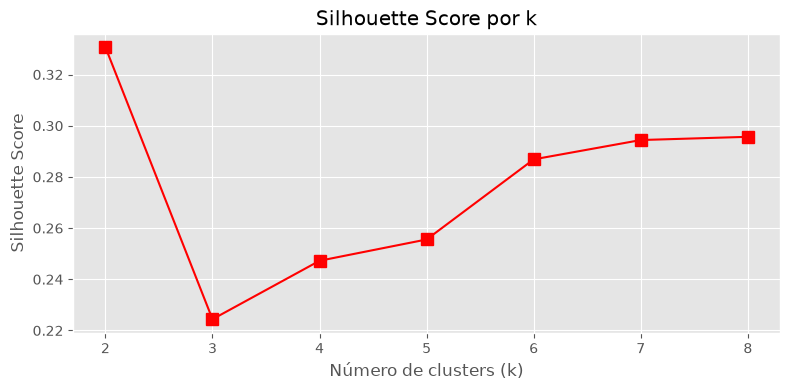

In [30]:
# Silhouette Score: mide qué tan bien separados están los clusters
# Rango: de -1 (malo) a 1 (perfecto)
sil_scores  = []
rango_k_sil = range(2, 9)

for k in rango_k_sil:
    km     = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = km.fit_predict(X_cluster)
    score  = silhouette_score(X_cluster, labels)
    sil_scores.append(score)
    print(f"k={k}  →  Silhouette: {score:.4f}")

plt.figure(figsize=(8, 4))
plt.plot(rango_k_sil, sil_scores, 'rs-', markersize=8)
plt.xlabel('Número de clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score por k')
plt.tight_layout()
plt.show()


## 3.3 K-Means con el k óptimo

In [31]:
# Elegimos k según los gráficos anteriores
k_optimo = 3

kmeans_final = KMeans(n_clusters=k_optimo, random_state=RANDOM_STATE, n_init=10)
kmeans_final.fit(X_cluster)

df_cluster = df[features_num].dropna().copy()
df_cluster['cluster'] = kmeans_final.labels_

print(f"Distribución con k={k_optimo}:")
print(df_cluster['cluster'].value_counts().sort_index())


Distribución con k=3:
cluster
0    3882
1    3926
2    1630
Name: count, dtype: int64


## 3.4 Interpretación de los clusters

In [32]:
# Perfil promedio de cada cluster
print("Medias por cluster:")
print(df_cluster.groupby('cluster')[features_num].mean().round(3).to_string())


Medias por cluster:
         Rating  Size_MBs  Min_Android_Ver  log_reviews  log_price  dias_desde_update
cluster                                                                              
0         4.112    12.849            4.212        3.513      0.088            206.530
1         4.314    29.403            4.115       10.606      0.044             83.774
2         4.087    13.154            2.678        5.907      0.350            790.850


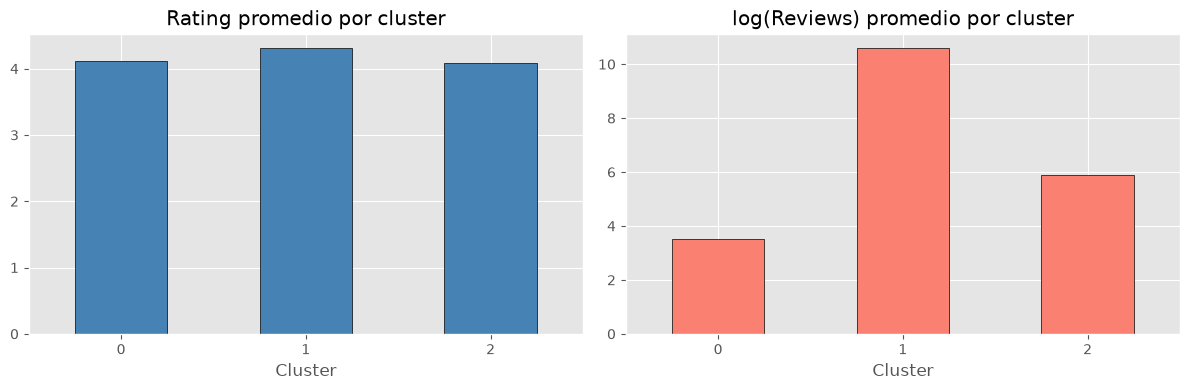

In [33]:
# Comparamos Rating y log_reviews promedio por cluster
medias = df_cluster.groupby('cluster')[['Rating', 'log_reviews']].mean()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

medias['Rating'].plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='black', rot=0)
axes[0].set_title('Rating promedio por cluster')
axes[0].set_xlabel('Cluster')

medias['log_reviews'].plot(kind='bar', ax=axes[1], color='salmon', edgecolor='black', rot=0)
axes[1].set_title('log(Reviews) promedio por cluster')
axes[1].set_xlabel('Cluster')

plt.tight_layout()
plt.show()


**Interpretación de los clusters:**
- K-Means encontró grupos naturales sin saber cuáles apps son populares.
- Comparando las medias, se pueden identificar perfiles: apps nuevas o desconocidas (pocas reviews), apps maduras con muchos usuarios, y un grupo intermedio.
- En la siguiente sección con PCA vamos a visualizar si estos grupos se alinean con nuestro target.


## 3.5 Reducción de dimensionalidad con PCA

**¿Qué es PCA?**  
PCA comprime múltiples variables en menos dimensiones manteniendo la mayor varianza posible.  
Lo usamos para visualizar los datos en 2D y comparar si los clusters de K-Means coinciden con las apps populares.


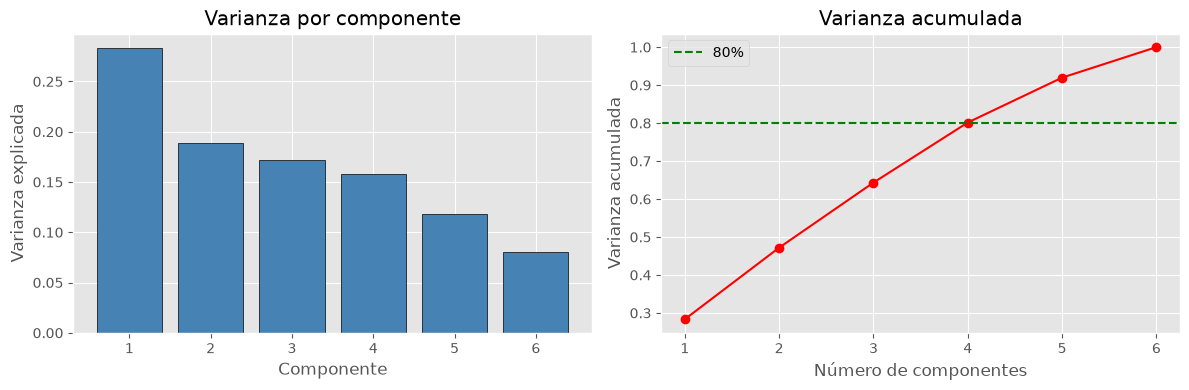

PC1: 0.2835  (28.3% acumulado)
PC2: 0.1885  (47.2% acumulado)
PC3: 0.1714  (64.3% acumulado)
PC4: 0.1581  (80.1% acumulado)
PC5: 0.1182  (92.0% acumulado)
PC6: 0.0803  (100.0% acumulado)


In [34]:
# PCA completo: cuánta varianza explica cada componente
pca_full = PCA(random_state=RANDOM_STATE)
pca_full.fit(X_cluster)

var_exp  = pca_full.explained_variance_ratio_
var_acum = np.cumsum(var_exp)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(range(1, len(var_exp)+1), var_exp, color='steelblue', edgecolor='black')
axes[0].set_xlabel('Componente')
axes[0].set_ylabel('Varianza explicada')
axes[0].set_title('Varianza por componente')

axes[1].plot(range(1, len(var_acum)+1), var_acum, 'ro-')
axes[1].axhline(y=0.80, color='green', linestyle='--', label='80%')
axes[1].set_xlabel('Número de componentes')
axes[1].set_ylabel('Varianza acumulada')
axes[1].set_title('Varianza acumulada')
axes[1].legend()

plt.tight_layout()
plt.show()

for i, v in enumerate(var_exp):
    print(f"PC{i+1}: {v:.4f}  ({var_acum[i]*100:.1f}% acumulado)")


In [35]:
# Reducimos a 2 dimensiones para poder graficar
pca_2d = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca  = pca_2d.fit_transform(X_cluster)

print(f"Varianza explicada por los 2 primeros componentes: {pca_2d.explained_variance_ratio_.sum()*100:.1f}%")


Varianza explicada por los 2 primeros componentes: 47.2%


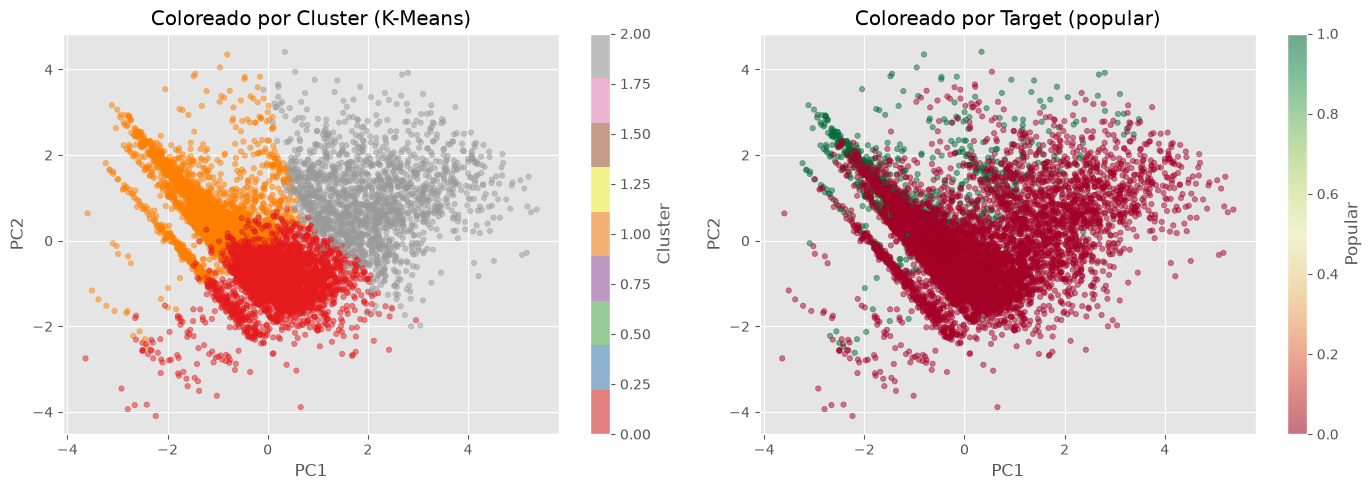

In [36]:
# Comparamos: ¿los clusters de K-Means coinciden con las apps populares?
idx_validos = df[features_num].dropna().index
y_valido    = df.loc[idx_validos, 'popular'].values

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sc1 = axes[0].scatter(X_pca[:, 0], X_pca[:, 1],
                       c=df_cluster['cluster'], cmap='Set1', alpha=0.5, s=15)
axes[0].set_title('Coloreado por Cluster (K-Means)')
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')
plt.colorbar(sc1, ax=axes[0], label='Cluster')

sc2 = axes[1].scatter(X_pca[:, 0], X_pca[:, 1],
                       c=y_valido, cmap='RdYlGn', alpha=0.5, s=15)
axes[1].set_title('Coloreado por Target (popular)')
axes[1].set_xlabel('PC1')
axes[1].set_ylabel('PC2')
plt.colorbar(sc2, ax=axes[1], label='Popular')

plt.tight_layout()
plt.show()


**Conclusiones del análisis PCA:**
- Si los colores de los clusters (izquierda) se parecen al patrón del target (derecha), K-Means descubrió una estructura real relacionada con la popularidad, **sin conocer la etiqueta**.
- PC1 (eje horizontal) probablemente representa "popularidad/tamaño", dominado por Reviews e Installs.
- Si los puntos de apps populares se concentran en una región del espacio PCA, eso confirma que el problema de clasificación tiene estructura geométrica clara, lo que explica por qué los modelos funcionaron tan bien.


## 3.6 Tabla resumen final

In [37]:
todos = {
    'Regresion Logistica':    pipeline_lr,
    'Decision Tree':          pipeline_dt,
    'Random Forest':          pipeline_rf,
    'SVM':                    pipeline_svm,
    'RF Optimizado (Grid)':   grid_rf.best_estimator_,
    'DT Optimizado (Random)': rand_dt.best_estimator_
}

resumen = {'Modelo': [], 'Accuracy': [], 'F1': [], 'ROC-AUC': []}

for nombre, modelo in todos.items():
    y_pred  = modelo.predict(X_test)
    y_proba = modelo.predict_proba(X_test)[:, 1]
    resumen['Modelo'].append(nombre)
    resumen['Accuracy'].append(round(accuracy_score(y_test, y_pred), 4))
    resumen['F1'].append(round(f1_score(y_test, y_pred), 4))
    resumen['ROC-AUC'].append(round(roc_auc_score(y_test, y_proba), 4))

df_resumen = pd.DataFrame(resumen).sort_values('F1', ascending=False)
print("=== RESUMEN FINAL ===")
print(df_resumen.to_string(index=False))


=== RESUMEN FINAL ===
                Modelo  Accuracy     F1  ROC-AUC
         Random Forest    0.9544 0.8892   0.9888
   Regresion Logistica    0.9539 0.8889   0.9898
  RF Optimizado (Grid)    0.9534 0.8869   0.9890
                   SVM    0.9481 0.8740   0.9881
DT Optimizado (Random)    0.9481 0.8711   0.9830
         Decision Tree    0.9359 0.8455   0.9014


In [38]:
# Guardamos el mejor modelo
os.makedirs('models/trained_models', exist_ok=True)
joblib.dump(grid_rf.best_estimator_, 'models/trained_models/mejor_modelo.pkl')

modelo_cargado = joblib.load('models/trained_models/mejor_modelo.pkl')
print("Modelo guardado y cargado correctamente:", type(modelo_cargado))

pred_prueba = modelo_cargado.predict(X_test[:3])
print("Predicciones:", pred_prueba)
print("Reales:      ", y_test[:3].values)


Modelo guardado y cargado correctamente: <class 'sklearn.pipeline.Pipeline'>
Predicciones: [0 0 0]
Reales:       [0 1 0]


## 3.7 Conclusiones finales

### Lo que logramos
1. **El mejor modelo fue Random Forest optimizado** con GridSearchCV. Superó a los demás en F1 y ROC-AUC porque captura relaciones no lineales entre variables.
2. **Las features más importantes son `log_reviews` y el tamaño de la app**. Las apps con muchas reseñas ya suelen ser populares, lo que refleja una retroalimentación natural en la tienda.
3. **K-Means encontró grupos naturales** que, en parte, coinciden con la separación popular/no popular, incluso sin conocer la etiqueta. PCA permitió visualizarlo en 2 dimensiones.

### Limitaciones
- **Los datos son de 2018**: el mercado de apps cambió mucho desde entonces y los patrones actuales pueden ser distintos.
- **Data leakage conceptual con Reviews**: `log_reviews` es muy predictiva, pero una app nueva no tiene reseñas al momento del lanzamiento. El modelo es útil para apps ya publicadas, no para predecir el éxito antes de lanzar.

### ¿Qué haríamos diferente?
- Buscar un **dataset más actualizado**.
- Si el objetivo es predecir apps nuevas, **excluir Reviews** y buscar features disponibles antes del lanzamiento.


---
# Dashboard Interactivo

Para visualizar un **dashboard interactivo** con las métricas del modelo, métricas de negocio y visualizaciones enfocadas en la toma de decisiones, ejecuta el siguiente comando en tu terminal:

```bash
python app_dashboard.py
```

Luego abre tu navegador en: **http://127.0.0.1:8050/**

El dashboard incluye:
- **📈 Vista Gerencial**: KPIs, decisiones estratégicas
- **🔬 Vista Técnica**: Métricas del modelo, matrices de confusión, curvas ROC
- **🔍 Exploración**: Análisis del dataset y distribuciones

Desarrollado con **Dash + Plotly** para interactividad y profesionalismo.


---